In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.datasets import imdb
from keras import models, layers
from sklearn.model_selection import train_test_split

In [17]:
# Load IMDB dataset (top 10,000 most frequent words)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = imdb.load_data(num_words=10000)

In [18]:
# Combine train and test data
data = np.concatenate((X_train_raw, X_test_raw), axis=0)
label = np.concatenate((y_train_raw, y_test_raw), axis=0)

<Axes: xlabel='label', ylabel='count'>

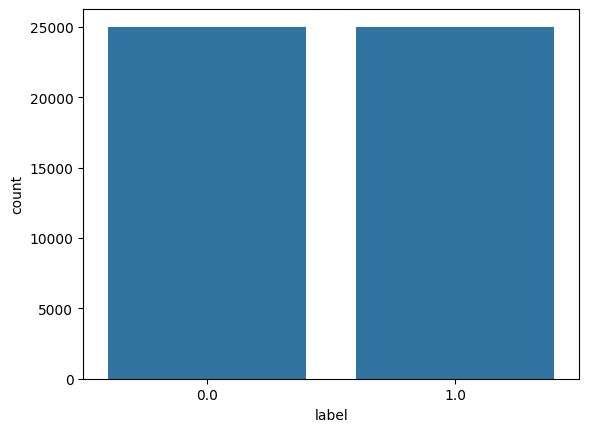

In [19]:
# Vectorization function
def vectorize(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

# Vectorize data
data = vectorize(data)
label = np.array(label).astype("float32")

# Visualize labels
labelDF = pd.DataFrame({'label': label})
sns.countplot(x='label', data=labelDF)

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data, label, test_size=0.20, random_state=1
)

In [21]:
# Build model
model = models.Sequential()
model.add(layers.Dense(50, activation="relu", input_shape=(10000,)))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

C:\Users\pawar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 50)                  │         500,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 505,201 (1.93 MB)

 Trainable params: 505,201 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Early stopping
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

In [23]:
# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [24]:
# Train model
results = model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=500,
    validation_data=(X_test, y_test),
    callbacks=[callback]
)

Epoch 1/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8221 - loss: 0.4022 - val_accuracy: 0.8961 - val_loss: 0.2554
Epoch 2/2
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9190 - loss: 0.2137 - val_accuracy: 0.8991 - val_loss: 0.2545


In [25]:
# Validation accuracy
print(np.mean(results.history["val_accuracy"]))

0.897599995136261


In [26]:
# Evaluate model
score = model.evaluate(X_test, y_test, batch_size=500)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8991 - loss: 0.2545 
Test loss: 0.2544821798801422
Test accuracy: 0.8991000056266785


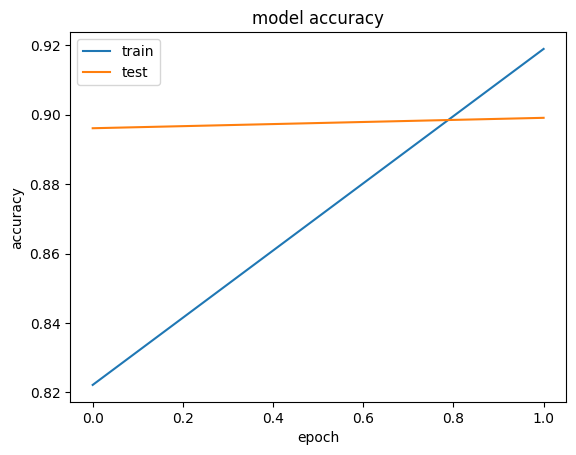

In [27]:
# Plot accuracy
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

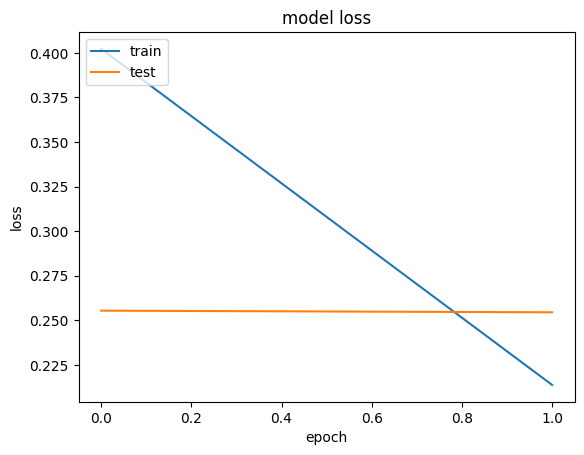

In [28]:
# Plot loss
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()